# Módulo 2: Modelos de Lenguaje de Gran Escala (LLMs)
## Notebook 1: Anatomía de la Arquitectura Transformer

La arquitectura **Transformer** (introducida por Vaswani et al. en 2017 en el paper *"Attention Is All You Need"*) es la base de todos los modelos de lenguaje modernos (GPT, Gemini, Llama, Claude, etc.).

En este notebook descompondremos paso a paso un Transformer en sus etapas fundamentales usando implementaciones simples en Python/Numpy y visualizaciones explicativas.

---  

## 1. Tokenización

La primera etapa consiste en convertir el texto legible en números. Un tokenizador divide la oración en piezas básicas (tokens) y asocia cada token con un número (Token ID) usando un vocabulario predefinido.

In [1]:
# Vocabulario simple de ejemplo
vocab = {"<PAD>": 0, "el": 1, "gato": 2, "duerme": 3, "en": 4, "la": 5, "alfombra": 6}

def tokenizar(texto):
    tokens = texto.lower().split()
    ids = [vocab.get(t, 0) for t in tokens]
    return tokens, ids

texto_ejemplo = "El gato duerme en la alfombra"
tokens, ids = tokenizar(texto_ejemplo)

print("Oración original:", texto_ejemplo)
print("Tokens:", tokens)
print("Token IDs:", ids)

Oración original: El gato duerme en la alfombra
Tokens: ['el', 'gato', 'duerme', 'en', 'la', 'alfombra']
Token IDs: [1, 2, 3, 4, 5, 6]


---  

## 2. Embeddings y Codificación Posicional

1. **Input Embeddings:** Mapean cada Token ID a un vector denso continuo de dimensión $d_{model}$.
2. **Codificación Posicional (PE):** Como los Transformers no procesan el texto secuencialmente (como las RNNs) sino en paralelo, se suma un vector de posición al embedding para inyectar orden secuencial. Se calcula usando funciones trigonométricas:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

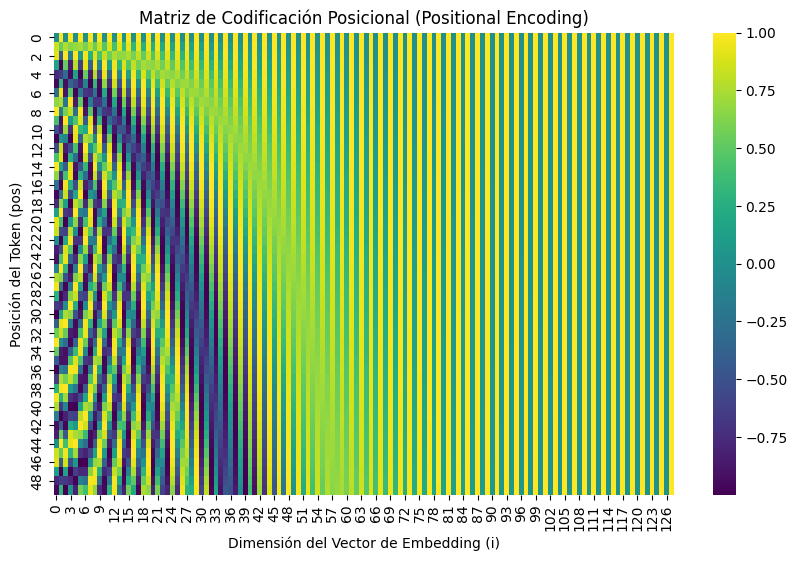

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_positional_encoding(max_seq_len, d_model):
    pe = np.zeros((max_seq_len, d_model))
    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(pos / (10000 ** (i / d_model)))
    return pe

# Generar codificación posicional (ej. secuencia de longitud 50 y dimensión 128)
seq_len, d_model = 50, 128
pe_matrix = get_positional_encoding(seq_len, d_model)

# Graficar la matriz
plt.figure(figsize=(10, 6))
sns.heatmap(pe_matrix, cmap="viridis", cbar=True)
plt.title("Matriz de Codificación Posicional (Positional Encoding)")
plt.xlabel("Dimensión del Vector de Embedding (i)")
plt.ylabel("Posición del Token (pos)")
plt.show()

---  

## 3. Auto-Atención (Self-Attention)

El mecanismo de auto-atención permite que los tokens interactúen entre sí, determinando cuánta relevancia ("atención") debe prestar un token a los demás dentro de la secuencia.

Se calculan tres vectores para cada token a través de proyecciones lineales:
*   **Query ($Q$):** Lo que el token busca.
*   **Key ($K$):** Lo que el token ofrece para ser buscado.
*   **Value ($V$):** El contenido de la información del token.

La fórmula de la atención escalada es:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

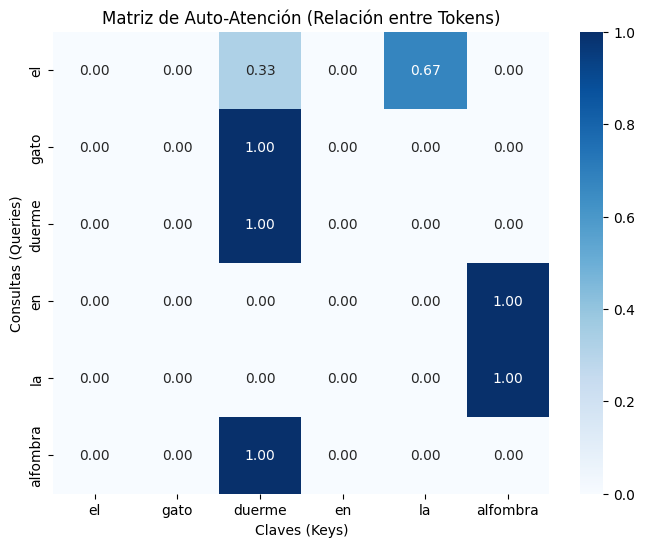

In [3]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def self_attention(Q, K, V):
    d_k = Q.shape[-1]
    # 1. Similitud mediante producto punto escalado
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    # 2. Pesos de atención usando Softmax
    attention_weights = softmax(scores)
    # 3. Suma ponderada de los valores V
    output = np.dot(attention_weights, V)
    return attention_weights, output

# Simular tokens y embeddings
tokens_sim = ["el", "gato", "duerme", "en", "la", "alfombra"]
n_tokens = len(tokens_sim)
d_k = 64

np.random.seed(42)
X = np.random.randn(n_tokens, d_k)

# Matrices de pesos simuladas
W_Q = np.random.randn(d_k, d_k)
W_K = np.random.randn(d_k, d_k)
W_V = np.random.randn(d_k, d_k)

# Proyecciones Q, K y V
Q = np.dot(X, W_Q)
K = np.dot(X, W_K)
V = np.dot(X, W_V)

# Simular manualmente una relación semántica fuerte para el ejemplo gráfico
Q[1] = K[2] * 2.0  # El Query de 'gato' (index 1) se enfoca en la Key de 'duerme' (index 2)
Q[5] = K[2] * 1.5  # El Query de 'alfombra' (index 5) se enfoca en la Key de 'duerme' (index 2)

attn_weights, attn_output = self_attention(Q, K, V)

# Graficar los pesos de atención
plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights, xticklabels=tokens_sim, yticklabels=tokens_sim, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de Auto-Atención (Relación entre Tokens)")
plt.xlabel("Claves (Keys)")
plt.ylabel("Consultas (Queries)")
plt.show()

---  

## 4. Redes Feed-Forward (FFN) y Normalización Residual

Cada bloque del Transformer contiene adicionalmente:
1. **Feed-Forward Network (FFN):** Una red totalmente conectada (MLP) que procesa cada posición del token de forma independiente.
2. **Conexiones Residuales y Normalización de Capas (LayerNorm):** Ayudan a estabilizar el entrenamiento y propagar los gradientes sin desvanecerse.

In [4]:
def feed_forward(x, W1, b1, W2, b2):
    # Primera capa con activación ReLU
    h = np.maximum(0, np.dot(x, W1) + b1)
    # Segunda capa de proyección lineal
    return np.dot(h, W2) + b2

def layer_norm(x, gamma=1.0, beta=0.0, eps=1e-5):
    mean = np.mean(x, axis=-1, keepdims=True)
    variance = np.var(x, axis=-1, keepdims=True)
    x_norm = (x - mean) / np.sqrt(variance + eps)
    return gamma * x_norm + beta

# Pesos simulados para la capa FFN
d_ff = 256
W1 = np.random.randn(d_k, d_ff)
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff, d_k)
b2 = np.zeros(d_k)

# Procesamiento completo de un bloque (Atención -> FFN -> Conexión Residual -> LayerNorm)
ffn_out = feed_forward(attn_output, W1, b1, W2, b2)
output_bloque = layer_norm(attn_output + ffn_out)

print("Dimensión de entrada al bloque:", attn_output.shape)
print("Dimensión de salida del bloque:", output_bloque.shape)

Dimensión de entrada al bloque: (6, 64)
Dimensión de salida del bloque: (6, 64)


---  

## 5. Capa Lineal y Softmax de Salida

Al final del modelo, el vector de salida correspondiente al último token se proyecta sobre la dimensión del vocabulario para generar puntuaciones (logits). Al aplicar una función softmax sobre los logits, obtenemos las probabilidades del siguiente token a generar.

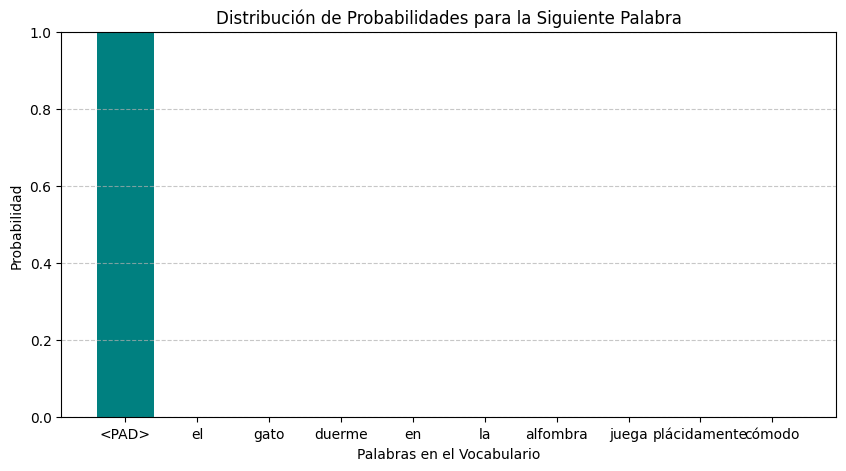

Palabra predicha: '<PAD>' (ID: 0)


In [5]:
# Simulación de proyección al vocabulario
vocab_size = 10
palabras_vocab = ["<PAD>", "el", "gato", "duerme", "en", "la", "alfombra", "juega", "plácidamente", "cómodo"]

# Tomar la representación del último token de la secuencia ("alfombra")
ultimo_token_vec = output_bloque[-1]

# Pesos de salida y cálculo de Logits
W_output = np.random.randn(d_k, vocab_size)
logits = np.dot(ultimo_token_vec, W_output)

# Simular un incremento manual para una palabra lógica del vocabulario (plácidamente)
logits[8] += 5.0

probabilities = softmax(logits)

# Graficar probabilidades de salida
plt.figure(figsize=(10, 5))
plt.bar(palabras_vocab, probabilities, color="teal")
plt.title("Distribución de Probabilidades para la Siguiente Palabra")
plt.xlabel("Palabras en el Vocabulario")
plt.ylabel("Probabilidad")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Palabra con mayor probabilidad
next_id = np.argmax(probabilities)
print(f"Palabra predicha: '{palabras_vocab[next_id]}' (ID: {next_id})")